# Paper figures: $\varepsilon$ vs $\rho$ (bound) vs utility

For every **(dataset, metric)** pair: as the DP guarantee $\varepsilon$ varies over a **shared,
dataset-consistent grid** ($\varepsilon = 0.1, 0.25, 0.5, 1, 2, 4, 8, 16, 32$ — the *same* $\varepsilon$
targets for every dataset), what protection $\rho$ is *bounded* and what task utility is *achieved*
under the same DP-SGD run (canonical recipe: LeNet-5 / WRN-16-4-GN / ResNet-18-GN, augmult, momentum, EMA).

Direction is **$\varepsilon \to \rho$** (forward): each shared-$\varepsilon$ noise multiplier → its
PRV $\varepsilon$ (at the fleet's own $q,T,n$) → the bound $\rho^\star$ at that noise, and the
test accuracy of the model trained at it (shared-$\varepsilon$ fleet, 3 seeds).

- **x-axis** $\varepsilon$ (PRV accountant, training config, $\delta=n^{-1.1}$), same range across datasets.
- **left y-axis** utility (test accuracy); **right y-axis** $\rho$.
- one curve = the **bound** ($\rho$), one = **utility**.

Also emitted: a LaTeX table per (dataset, metric) with columns $\varepsilon,\ \rho,\ $utility.
Utility is metric-independent (same trained model); only the $\rho\!\leftrightarrow\!\varepsilon$
map differs between MSE and LPIPS.

**Source of truth:** the SHARED target-$\varepsilon$ fleet only — `shared_eps_fleet_params.tsv`
(the consistent $\varepsilon$ grid) + `results/utility/runs/` (its runs, which carry
$q,T,$batch) + the bounds. The old per-dataset $\rho$-level nm-tables are **not** read (that
path is retired on purpose; the $\rho$-grid runs are archived).

In [1]:
import warnings   # known, benign library warnings (they would print local install paths into the outputs):
warnings.filterwarnings("ignore", message="Optimal order is the largest alpha")   # opacus's PRV accountant sizes its mesh with an RDP bound
warnings.filterwarnings("ignore", message="The parameter 'pretrained' is deprecated")   # inside the lpips package
warnings.filterwarnings("ignore", message="Arguments other than a weight enum")         # inside the lpips package
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import glob, json, math, os, csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

ROOT = Path.cwd() if (Path.cwd() / "results").exists() else Path.cwd().parent
os.chdir(ROOT); import sys; sys.path.insert(0, str(ROOT))
from src.privacy.accounting import compute_epsilon_prv
from src.bound.rho import rho_at_schedule

C_RHO  = "#0072B2"   # blue  = bound rho
C_UTIL = "#009E73"   # green = utility
plt.rcParams.update({"axes.spines.top": False, "font.size": 11, "figure.dpi": 120})

# canonical model whose utility we report, per dataset
CANON_MODEL = {"mnist": "lenet5", "cifar10": "wrn16_4_gn",
               "celeba": "resnet18gn", "imagenette": "resnet18gn"}
DATASETS = os.environ.get("PAPER_DATASETS", "mnist cifar10 celeba imagenette").split()
METRICS = ["mse", "lpips"]
from src.bound.rho import LPIPS_BOUND_DIR as _LPIPS_BOUND_DIR
def metrics_for(ds):   # LPIPS only where Phi is admissible (not ImageNette: Phi's AlexNet was trained on ImageNet)
    return [me for me in METRICS if me == "mse" or ds in _LPIPS_BOUND_DIR]

import functools

# ── the shared target-epsilon fleet is the only source of this figure: its params TSV (the eps grid, the SAME
# for every dataset) and its run records (which carry sampling_rate = q, total_steps = T, batch_size -> n).
FLEET_TSV = ROOT / "results/utility/shared_eps_fleet_params.tsv"
assert FLEET_TSV.exists(), (
    f"shared-eps fleet params missing: {FLEET_TSV}.  This figure requires the consistent-epsilon "
    f"fleet; the old rho-grid nm-tables are intentionally NOT a fallback.")

@functools.lru_cache(maxsize=1)
def _shared_eps_nms():
    """Per-dataset noise multipliers of the SHARED target-epsilon fleet (eps=0.1..32, the SAME
    eps grid for every dataset).  Source: the fleet params tsv (ds model C nm lr seed)."""
    d = defaultdict(set)
    rows = list(csv.reader(open(FLEET_TSV), delimiter="\t"))
    for r in rows:
        if len(r) < 6: continue
        try: d[r[0]].add(float(r[3]))
        except Exception: pass
    return {k: sorted(v) for k, v in d.items()}

@functools.lru_cache(maxsize=1)
def _all_runs():
    """Load every run JSON ONCE (they were re-globbed + re-parsed on every lookup -> slow)."""
    runs = []
    for f in glob.glob(str(ROOT / "results/utility/runs/*.json")):
        try: runs.append(json.load(open(f)))
        except Exception: pass
    return runs

@functools.lru_cache(maxsize=None)
def _fleet_params(dataset, model):
    """(q, T, n) for the shared-eps fleet, read from ITS OWN runs (sampling_rate, total_steps,
    batch_size) -- NOT the retired rho-grid nm-table.  n = round(batch / q).  None if no run."""
    for r in _all_runs():
        if r.get("dataset") != dataset or r.get("model_name") != model: continue
        q, T, b = r.get("sampling_rate"), r.get("total_steps"), r.get("batch_size")
        if q and T and b:
            return float(q), int(T), int(round(float(b) / float(q)))
    return None

_eps = functools.lru_cache(maxsize=None)(compute_epsilon_prv)   # memoised PRV accountant

def load_utility(dataset, model):
    """nm(float) -> (mean, std) test_acc over seeds (DP runs only, nm>0)."""
    acc = defaultdict(list)
    for r in _all_runs():
        if r.get("dataset") != dataset or r.get("model_name") != model: continue
        nm = float(r.get("noise_multiplier", -1))
        if nm <= 0: continue
        acc[round(nm, 6)].append(float(r["test_acc"]))
    return {k: (float(np.mean(v)), float(np.std(v))) for k, v in acc.items()}

def match_acc(util, nm, rtol=1e-3):
    best = None
    for k, v in util.items():
        if abs(k - nm) <= rtol * max(nm, 1e-9):
            best = v
    return best
# utility y-axis range: random-guess floor (1/num_classes) -> non-private ceiling
RANDOM_GUESS = {"mnist": 0.1, "cifar10": 0.1, "celeba": 0.5, "imagenette": 0.1}

def npriv(ds, model):
    """Non-private (sigma=0, C=inf) test accuracy = the no-DP ceiling."""
    accs = [float(r["test_acc"]) for r in _all_runs()
            if r.get("dataset") == ds and r.get("model_name") == model
            and float(r.get("noise_multiplier", -1)) == 0
            and float(r.get("max_grad_norm", 0)) >= 1e6]
    return max(accs) if accs else None


## Assemble the (ε, ρ, utility) rows per (dataset, metric)

In [2]:
@functools.lru_cache(maxsize=None)
def rows_for(dataset, metric):
    """Rows on the SHARED target-epsilon grid (eps=0.1..32, consistent across datasets), sourced
    ENTIRELY from the shared-eps fleet (no rho-grid nm-table): for each shared-eps nm -> its PRV eps
    (at the fleet's own q,T,n), the bound rho at that nm (rmse-fraction for MSE, rho for LPIPS),
    and the matched utility (3 seeds).  A dataset with no fleet runs -> None (panel shows 'no data')."""
    model = CANON_MODEL[dataset]
    fp = _fleet_params(dataset, model)
    if fp is None: return None, None
    q, T, n = fp
    delta = n ** -1.1
    util = load_utility(dataset, model)
    nms = _shared_eps_nms().get(dataset, [])
    rows = []
    def _rho(nm):
        try:
            f = rho_at_schedule(dataset, nm, q, T, metric)
            return f["rho"]
        except Exception:
            return None
    for nm in nms:
        eps = _eps(nm, delta, q, T)
        rho = _rho(nm)                                    # bound (LCB entropy + worst-case gamma)
        if rho is None: continue
        a = match_acc(util, nm)
        rows.append(dict(p=rho, rho=rho, nm=nm, eps=eps,
                         acc=(a[0] if a else None), acc_sd=(a[1] if a else None)))
    rows.sort(key=lambda r: r["eps"])
    return (rows, dict(model=model, T=T, q=q, delta=delta, n=n)) if rows else (None, None)

for ds in DATASETS:
    for me in METRICS:
        rows, meta = rows_for(ds, me)
        if not rows: print(f"{ds}/{me}: no data (fleet runs or bound missing?)"); continue
        have = sum(r["acc"] is not None for r in rows)
        eps = [r["eps"] for r in rows]
        print(f"{ds}/{me}: {len(rows)} shared-eps levels (eps {min(eps):.2f}..{max(eps):.1f}), "
              f"{have} with utility (model={meta['model']})")

mnist/mse: 11 shared-eps levels (eps 0.10..128.0), 11 with utility (model=lenet5)
mnist/lpips: 11 shared-eps levels (eps 0.10..128.0), 11 with utility (model=lenet5)


cifar10/mse: 11 shared-eps levels (eps 0.10..128.0), 11 with utility (model=wrn16_4_gn)
cifar10/lpips: 11 shared-eps levels (eps 0.10..128.0), 11 with utility (model=wrn16_4_gn)
celeba/mse: 11 shared-eps levels (eps 0.10..128.0), 11 with utility (model=resnet18gn)


celeba/lpips: 11 shared-eps levels (eps 0.10..128.0), 11 with utility (model=resnet18gn)


imagenette/mse: 11 shared-eps levels (eps 0.10..128.0), 11 with utility (model=resnet18gn)
imagenette/lpips: no data (fleet runs or bound missing?)


## The dual-axis figures — one per (dataset, metric)

Both axes share the $[0,1]$ range (both quantities are fractions), so the two curves are directly comparable; the right ($\rho$) axis is coloured to its curve, the left (utility) axis to its own.

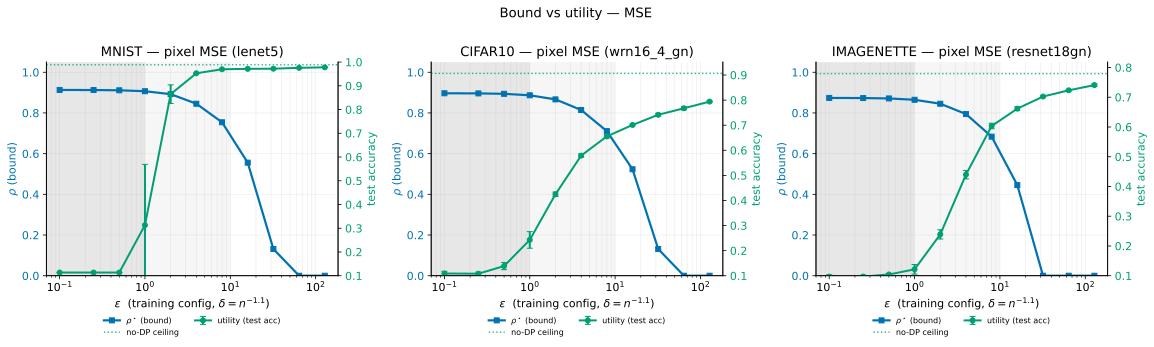

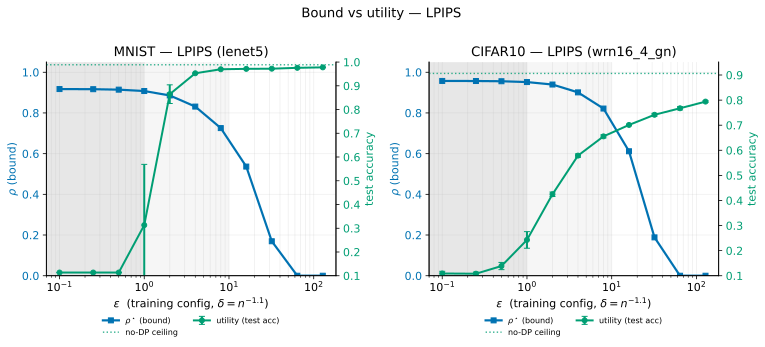

saved figures/utility_*.pdf


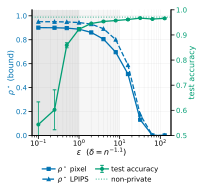

saved figures/utility_celeba_paper.pdf


In [3]:
def panel(ax, dataset, metric, show_legend=True, title=None, ylabel_left=True, ylabel_right=True, scale=1.0):
    rows, meta = rows_for(dataset, metric)
    if not rows:
        ax.set_title(f"{dataset}/{metric}: no data"); ax.axis("off"); return
    eps = np.array([r["eps"] for r in rows])
    rho = np.array([r["rho"] for r in rows])
    ax.plot(eps, rho, "s-", color=C_RHO, lw=2.2*scale, ms=5*scale, label=r"$\rho^\star$ (bound)")
    ax.set_xscale("log"); ax.set_ylim(0, 1.05)
    ax.set_xlabel(r"$\varepsilon$  (training config, $\delta=n^{-1.1}$)")
    ax.set_ylabel(r"$\rho$ (bound)" if ylabel_left else "", color=C_RHO)
    ax.tick_params(axis="y", labelcolor=C_RHO)
    ax.grid(True, which="both", alpha=0.2)
    # epsilon-regime shading: eps<1 strong (good privacy), 1<=eps<10 light (weak/common), eps>=10 none
    x0, x1 = ax.get_xlim()
    ax.axvspan(x0, min(1.0, x1), color="0.4", alpha=0.16, lw=0, zorder=0)
    if x1 > 1.0: ax.axvspan(1.0, min(10.0, x1), color="0.4", alpha=0.06, lw=0, zorder=0)
    ax.set_xlim(x0, x1)

    ax2 = ax.twinx(); ax2.spines["top"].set_visible(False)
    um = np.array([(r["acc"] if r["acc"] is not None else np.nan) for r in rows])
    usd = np.array([(r["acc_sd"] if r["acc_sd"] is not None else 0.0) for r in rows])
    m = ~np.isnan(um)
    if m.any():
        ax2.errorbar(eps[m], um[m], yerr=usd[m], fmt="o-", color=C_UTIL, lw=2.0*scale,
                     ms=5*scale, capsize=3*scale, label="utility (test acc)")
    lo = RANDOM_GUESS.get(dataset, 0.0)
    ceil = npriv(dataset, meta["model"])                    # no-DP ceiling (None until the baseline lands)
    cand = list(um[m]) if m.any() else []
    if ceil is not None and np.isfinite(ceil): cand.append(ceil)
    top = max(cand) if cand else 1.0
    ax2.set_ylim(lo, min(1.0, top * 1.05))                  # random guess -> a little above the max utility
    if ceil is not None and np.isfinite(ceil):
        ax2.axhline(ceil, color=C_UTIL, ls=":", lw=1.4*scale, alpha=0.8, label="no-DP ceiling")
    ax2.set_ylabel("test accuracy" if ylabel_right else "", color=C_UTIL)
    ax2.tick_params(axis="y", labelcolor=C_UTIL)
    ax.set_title(title if title is not None else
                 f"{dataset.upper()} — {'pixel MSE' if metric=='mse' else 'LPIPS'} "
                 f"({meta['model']})")
    # combined legend BELOW the panel (out of the plot area, so it never obscures the curves)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax._combined_legend = (h1 + h2, l1 + l2)
    if show_legend:
        ax.legend(h1 + h2, l1 + l2, frameon=False, loc="upper center",
                  bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=8)

# CelebA gets its own dedicated side-by-side figure below (for the paper) -- excluded here so the
# combined multi-dataset grid isn't redundant with it.
GRID_DATASETS = [d for d in DATASETS if d != "celeba"]
FIG_DIR = ROOT / "figures"   # every figure, under the name the paper includes
FIG_DIR.mkdir(exist_ok=True)
for me in METRICS:
    ds_have = [d for d in GRID_DATASETS if rows_for(d, me)[0]]
    if not ds_have: continue
    ncol = min(3, len(ds_have)); nrow = math.ceil(len(ds_have)/ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.4*ncol, 4.9*nrow), squeeze=False)
    for ax, ds in zip(axes.flat, ds_have): panel(ax, ds, me)
    for ax in axes.flat[len(ds_have):]: ax.axis("off")
    fig.suptitle(f"Bound vs utility — {'MSE' if me=='mse' else 'LPIPS'}", y=1.01)
    fig.tight_layout(h_pad=3.0); fig.savefig(FIG_DIR / f"utility_{me}.pdf", bbox_inches="tight")
    plt.show()

# per-(dataset,metric) standalone PDFs
for me in METRICS:
    for ds in DATASETS:
        if not rows_for(ds, me)[0]: continue
        fig, ax = plt.subplots(figsize=(5.6, 4.4)); panel(ax, ds, me)
        fig.tight_layout(); fig.savefig(FIG_DIR / f"utility_{ds}_{me}.pdf", bbox_inches="tight")
        plt.close(fig)
print("saved figures/utility_*.pdf")

# ---- dedicated CelebA figure (paper Fig. 1): ONE panel, both bounds (pixel MSE, LPIPS) on the left axis and the
# utility they share (same runs) on the right; 2.7 x 2.2 in, 7-8 pt fonts, legend below in 2 columns. ----
rows_px, meta_c = rows_for("celeba", "mse"); rows_lp, _ = rows_for("celeba", "lpips")
if rows_px or rows_lp:
    with plt.rc_context({"font.size": 7, "axes.titlesize": 8, "axes.labelsize": 8,
                          "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
                          "xtick.major.pad": 1.5, "ytick.major.pad": 1.5}):
        fig, ax = plt.subplots(figsize=(2.7, 2.2))
        for rows, fmt, ls, lab in [(rows_px, "s", "-", r"$\rho^\star$ pixel"),
                                   (rows_lp, "^", "--", r"$\rho^\star$ LPIPS")]:
            if rows:
                ax.plot([r["eps"] for r in rows], [r["rho"] for r in rows], marker=fmt, ls=ls, color=C_RHO,
                        lw=1.3, ms=3.2, label=lab)
        ax.set_xscale("log"); ax.set_ylim(0, 1.05)
        ax.set_xlabel(r"$\varepsilon$  ($\delta=n^{-1.1}$)", labelpad=1)
        ax.set_ylabel(r"$\rho^\star$ (bound)", color=C_RHO, labelpad=1)
        ax.tick_params(axis="y", labelcolor=C_RHO); ax.grid(True, which="both", alpha=0.2, lw=0.5)
        x0, x1 = ax.get_xlim()                                  # epsilon-regime shading, as in the other panels
        ax.axvspan(x0, min(1.0, x1), color="0.4", alpha=0.16, lw=0, zorder=0)
        if x1 > 1.0: ax.axvspan(1.0, min(10.0, x1), color="0.4", alpha=0.06, lw=0, zorder=0)
        ax.set_xlim(x0, x1)
        ax2 = ax.twinx(); ax2.spines["top"].set_visible(False)
        rows_u = rows_px or rows_lp                              # utility is the same runs for both metrics
        eps = np.array([r["eps"] for r in rows_u])
        um = np.array([(r["acc"] if r["acc"] is not None else np.nan) for r in rows_u])
        usd = np.array([(r["acc_sd"] if r["acc_sd"] is not None else 0.0) for r in rows_u]); m = ~np.isnan(um)
        ax2.errorbar(eps[m], um[m], yerr=usd[m], fmt="o-", color=C_UTIL, lw=1.3, ms=3.0, capsize=1.8,
                     elinewidth=0.8, label="test accuracy")
        ceil = npriv("celeba", meta_c["model"])
        cand = list(um[m]) + ([ceil] if ceil is not None and np.isfinite(ceil) else [])
        ax2.set_ylim(RANDOM_GUESS.get("celeba", 0.0), min(1.0, max(cand) * 1.05))
        if ceil is not None and np.isfinite(ceil):
            ax2.axhline(ceil, color=C_UTIL, ls=":", lw=1.0, alpha=0.8, label="non-private")
        ax2.set_ylabel("test accuracy", color=C_UTIL, labelpad=1); ax2.tick_params(axis="y", labelcolor=C_UTIL)
        h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
        o2 = sorted(range(len(l2)), key=lambda t: l2[t] != "test accuracy")          # curve before its ceiling
        h2, l2 = [h2[t] for t in o2], [l2[t] for t in o2]
        fig.tight_layout(pad=0.2)
        fig.legend(h1 + h2, l1 + l2, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=2,
                   columnspacing=1.0, handletextpad=0.4, handlelength=1.8, borderaxespad=0.0)
        fig.savefig(FIG_DIR / "utility_celeba_paper.pdf", bbox_inches="tight", pad_inches=0.02)
        plt.show()
    print("saved figures/utility_celeba_paper.pdf")


## LaTeX tables — ε, ρ, utility (one `table` per dataset/metric)

In [4]:
def latex_table(dataset, metric):
    rows, meta = rows_for(dataset, metric)
    if not rows: return f"% {dataset}/{metric}: no data\n"
    metname = "pixel MSE" if metric == "mse" else "LPIPS"
    lines = [r"\begin{table}[t]", r"  \centering",
             rf"  \caption{{{dataset.upper()} ({metname}): protection $\rho$ (bound) and "
             rf"achieved utility ({meta['model']}) versus the DP guarantee "
             rf"$\varepsilon$ (at $\delta=n^{{-1.1}}$).}}",
             rf"  \label{{tab:util_{dataset}_{metric}}}",
             r"  \begin{tabular}{r r r}", r"    \toprule",
             r"    $\varepsilon$ & $\rho$ (bound) & utility (test acc) \\",
             r"    \midrule"]
    for r in rows:
        acc = "--" if r["acc"] is None else (
            f"{r['acc']:.3f}" + (f"\\,$\\pm$\\,{r['acc_sd']:.3f}" if r['acc_sd'] else ""))
        eps = "$>10^3$" if r["eps"] > 1e3 else f"{r['eps']:.2f}"
        lines.append(rf"    {eps} & {r['rho']:.2f} & {acc} \\")
    lines += [r"    \bottomrule", r"  \end{tabular}", r"\end{table}", ""]
    return "\n".join(lines)

TAB_DIR = ROOT / "tables"; TAB_DIR.mkdir(exist_ok=True)
for me in METRICS:
    for ds in DATASETS:
        if me not in metrics_for(ds): continue
        tex = latex_table(ds, me)
        (TAB_DIR / f"util_{ds}_{me}.tex").write_text(tex)
        if "no data" not in tex: print(tex)
print("wrote tables/util_<ds>_<metric>.tex")

\begin{table}[t]
  \centering
  \caption{MNIST (pixel MSE): protection $\rho$ (bound) and achieved utility (lenet5) versus the DP guarantee $\varepsilon$ (at $\delta=n^{-1.1}$).}
  \label{tab:util_mnist_mse}
  \begin{tabular}{r r r}
    \toprule
    $\varepsilon$ & $\rho$ (bound) & utility (test acc) \\
    \midrule
    0.10 & 0.91 & 0.113\,$\pm$\,0.000 \\
    0.25 & 0.91 & 0.113\,$\pm$\,0.000 \\
    0.50 & 0.91 & 0.113\,$\pm$\,0.000 \\
    1.00 & 0.91 & 0.313\,$\pm$\,0.256 \\
    2.00 & 0.89 & 0.865\,$\pm$\,0.039 \\
    4.00 & 0.85 & 0.953\,$\pm$\,0.001 \\
    8.00 & 0.75 & 0.970\,$\pm$\,0.001 \\
    16.00 & 0.56 & 0.971\,$\pm$\,0.002 \\
    32.00 & 0.13 & 0.972\,$\pm$\,0.001 \\
    64.00 & 0.00 & 0.976\,$\pm$\,0.000 \\
    128.00 & 0.00 & 0.978\,$\pm$\,0.001 \\
    \bottomrule
  \end{tabular}
\end{table}

\begin{table}[t]
  \centering
  \caption{CIFAR10 (pixel MSE): protection $\rho$ (bound) and achieved utility (wrn16_4_gn) versus the DP guarantee $\varepsilon$ (at $\delta=n^{-1.1}$

## Notes
- $\rho$ is the **bound** protection at that $\varepsilon$ (forward map: the shared-$\varepsilon$ noise → the bound $\rho^\star$ at that noise); utility is the **measured** accuracy of the model trained at the same noise.
- The $\varepsilon$ grid is **shared across all datasets** ($0.1$–$32$), so the panels are directly comparable — unlike the retired $\rho$-level grid, whose $\varepsilon$ differed per dataset.
- Utility is identical across the MSE and LPIPS panels for a dataset (same DP-SGD run); only the $\rho$ bound at a given $\varepsilon$ moves.
- The $(C{=}\infty,\sigma{=}0)$ non-private accuracy is the no-DP ceiling (dotted line).
- Re-run: `sbatch --export=ALL,NB=notebooks/paper_utility_curves.ipynb reproduce/slurm_exec_notebook.sh`.

In [5]:
# ---- tab:spectrum: rows = the paper's target eps, columns = (acc, rho*_px, rho*_lpips) per dataset ----
# Both bounds are evaluated at the TRAINING configuration (q, T) of the fleet -- the same values the
# figures and util_<ds>_<metric>.tex show.
NAME = {"mnist": "MNIST", "cifar10": "CIFAR-10", "celeba": "CelebA", "imagenette": "ImageNette"}
PAPER_EPS = [1, 2, 4, 8, 16, 32, 64]

def at_eps(ds, me, target, rtol=0.05):
    """The fleet row whose PRV eps is the paper's target eps (fleet sigma was solved for these targets)."""
    rows, _ = rows_for(ds, me)
    r = min(rows, key=lambda r: abs(math.log(r["eps"] / target)))
    assert abs(r["eps"] / target - 1) < rtol, f"{ds}/{me}: no fleet row at eps={target} (nearest {r['eps']:.3f})"
    return r

def spectrum_tex():
    ncol = {d: 3 if "lpips" in metrics_for(d) else 2 for d in DATASETS}      # ImageNette: no LPIPS bound, no column
    first = [2 + sum(ncol[x] for x in DATASETS[:i]) for i in range(len(DATASETS))]
    L = [r"\begin{table}[htbp]\centering\footnotesize\setlength{\tabcolsep}{3pt}",
         r"\begin{tabular}{r " + " ".join("c" * ncol[d] for d in DATASETS) + "}", r"\toprule",
         " & " + " & ".join(rf"\multicolumn{{{ncol[d]}}}{{c}}{{{NAME[d]}}}" for d in DATASETS) + r" \\",
         "".join(rf"\cmidrule(lr){{{f}-{f + ncol[d] - 1}}}" for f, d in zip(first, DATASETS)),
         r"$\varepsilon$ & " + " & ".join(r"acc. & $\rhostarpx$" + (r" & $\rhostarlp$" if ncol[d] == 3 else "")
                                          for d in DATASETS) + r" \\",
         r"\midrule"]
    for e in PAPER_EPS:
        cells = []
        for ds in DATASETS:
            rm = at_eps(ds, "mse", e)
            cells += ["--" if rm["acc"] is None else f"{rm['acc']:.3f}", f"{rm['rho']:.3f}"]
            if ncol[ds] == 3:
                rl = at_eps(ds, "lpips", e)
                assert abs(rm["nm"] - rl["nm"]) < 1e-9
                cells.append(f"{rl['rho']:.3f}")
        dag = r"^{\dagger}" if e > 10 else ""
        L.append(rf"${e}{dag}$ & " + " & ".join(cells) + r" \\")
    L.append(r"\midrule")
    L.append("non-priv. & " + " & ".join(
        f"{npriv(ds, CANON_MODEL[ds]):.3f}" + " & ---" * (ncol[ds] - 1) for ds in DATASETS) + r" \\")
    L += [r"\bottomrule", r"\end{tabular}",
          r"\caption{Values behind \Cref{fig:spectrum_headline,fig:spectrum_all}: test accuracy (mean over 3 seeds) "
          r"and the pixel and perceptual bounds at each target $\varepsilon$, each a $95\%$ lower bound. $\dagger$: "
          r"the $\varepsilon>10$ band of \citet{ponomareva2023dp}.}",
          r"\label{tab:spectrum}", r"\end{table}", ""]
    return "\n".join(L)

tex = spectrum_tex()
TAB_DIR.mkdir(exist_ok=True)
(TAB_DIR / "spectrum.tex").write_text(tex)
print(tex)

# consistency: the table's LPIPS column must equal the util_<ds>_lpips rows (the old q=1,T=1 bug)
for ds in [d for d in DATASETS if "lpips" in metrics_for(d)]:
    for e in PAPER_EPS:
        r = at_eps(ds, "lpips", e)
        f = rho_at_schedule(ds, r["nm"], *_fleet_params(ds, CANON_MODEL[ds])[:2], "lpips")["rho"]
        assert abs(f - r["rho"]) < 1e-12
print("OK: tab:spectrum LPIPS column is at the training (q, T)")

\begin{table}[htbp]\centering\footnotesize\setlength{\tabcolsep}{3pt}
\begin{tabular}{r ccc ccc ccc cc}
\toprule
 & \multicolumn{3}{c}{MNIST} & \multicolumn{3}{c}{CIFAR-10} & \multicolumn{3}{c}{CelebA} & \multicolumn{2}{c}{ImageNette} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}\cmidrule(lr){8-10}\cmidrule(lr){11-12}
$\varepsilon$ & acc. & $\rhostarpx$ & $\rhostarlp$ & acc. & $\rhostarpx$ & $\rhostarlp$ & acc. & $\rhostarpx$ & $\rhostarlp$ & acc. & $\rhostarpx$ \\
\midrule
$1$ & 0.313 & 0.907 & 0.908 & 0.243 & 0.887 & 0.952 & 0.923 & 0.888 & 0.944 & 0.122 & 0.865 \\
$2$ & 0.865 & 0.892 & 0.886 & 0.425 & 0.867 & 0.940 & 0.946 & 0.861 & 0.931 & 0.239 & 0.845 \\
$4$ & 0.953 & 0.845 & 0.831 & 0.579 & 0.815 & 0.901 & 0.954 & 0.805 & 0.892 & 0.440 & 0.795 \\
$8$ & 0.970 & 0.754 & 0.726 & 0.655 & 0.711 & 0.822 & 0.957 & 0.696 & 0.801 & 0.603 & 0.683 \\
$16^{\dagger}$ & 0.971 & 0.556 & 0.536 & 0.701 & 0.523 & 0.612 & 0.961 & 0.513 & 0.588 & 0.662 & 0.445 \\
$32^{\dagger}$ & 0.972 & 0.131 & 0.169 & 

## Paper claims backed by this notebook (beyond the figures)
Each cell below prints the numbers a sentence or table of the paper quotes, with the paper location in
the heading. `CHECK` lines test a qualitative claim against the data and print `TRUE`/`FALSE`; a
`FALSE` means the **paper text** must change (the data is the source of truth).

### tab:spectrum_full — mechanism internals: γ, σ, binding pair (k*, ν²*) per ε
Also backs the Table 5 caption (*"k⋆ grows with γ overall up to single grid steps on CelebA"*) and App.
`app:exp_entropy` *Grid* (*"The selected pair often lies on the boundary of the grid (Table 5): k⋆ = max K at ε ≥ 8 in
pixel space on MNIST, CIFAR-10 and ImageNette (and at ε = 16 on CelebA), and at almost every leakage in LPIPS space;
ν²⋆ reaches an end of N in a few places"*).

In [6]:
from src.bound.rho import load_bound
from src.bound.rho import read_bound
from src.bound.rho import PIXEL_BOUND_DIR, LPIPS_BOUND_DIR

def grid_of(ds, me):
    c = read_bound(Path((PIXEL_BOUND_DIR if me == "mse" else LPIPS_BOUND_DIR)[ds]) / "entropy_bound.json")
    return list(c["grid_k"]), list(c["grid_nu2"])

def detail(ds, me, nm):
    q, T, _ = _fleet_params(ds, CANON_MODEL[ds])
    return rho_at_schedule(ds, nm, q, T, me)

full = []
for ds in DATASETS:
    for e in PAPER_EPS:
        r = at_eps(ds, "mse", e)
        fp = detail(ds, "mse", r["nm"])
        fl = detail(ds, "lpips", r["nm"]) if "lpips" in metrics_for(ds) else dict(k_star="na", nu2_star="na", rho=None)
        full.append(dict(ds=ds, eps=e, eps_prv=r["eps"], nm=r["nm"], gamma=fp["gamma_bits"],
                         k_px=fp["k_star"], nu_px=fp["nu2_star"], rho_px=fp["rho"],
                         k_lp=fl["k_star"], nu_lp=fl["nu2_star"], rho_lp=fl["rho"]))
print(f"{'dataset':<11}{'eps':>5}{'eps_PRV':>9}{'gamma(bits)':>12}{'sigma':>9}{'k*px':>6}{'k*lp':>6}{'nu2*px':>8}{'nu2*lp':>8}")
for r in full:
    print(f"{r['ds']:<11}{r['eps']:>5}{r['eps_prv']:>9.3f}{r['gamma']:>12.4f}{r['nm']:>9.4f}"
          f"{str(r['k_px']):>6}{str(r['k_lp']):>6}{str(r['nu_px']):>8}{str(r['nu_lp']):>8}")

L = [r"\begin{table}[htbp]\centering\small", r"\begin{tabular}{l r r r cc cc}", r"\toprule",
     r"Dataset & $\varepsilon$ & $\gamma$ (bits) & $\sigma$ & \multicolumn{2}{c}{$k^\star$ (pix / $\lpipsmap$)} & "
     r"\multicolumn{2}{c}{$\nu^{2\star}$ (pix / $\lpipsmap$)} \\", r"\midrule"]
for ds in DATASETS:
    rs = [r for r in full if r["ds"] == ds]
    for i, r in enumerate(rs):
        f = lambda v: "n/a" if v == "na" else ("--" if v is None else f"{v:g}")
        L.append((NAME[ds] if i == 0 else "") + rf" & ${r['eps']}$ & {r['gamma']:.3f} & {r['nm']:.3f} & "
                 rf"{f(r['k_px'])} & {f(r['k_lp'])} & {f(r['nu_px'])} & {f(r['nu_lp'])} \\")
    L.append(r"\midrule")
L[-1] = r"\bottomrule"
L += [r"\end{tabular}", r"\caption{Mechanism internals behind \Cref{fig:spectrum_headline,fig:spectrum_all}: the leakage each "
      r"configuration incurs, the noise multiplier achieving it, and the binding pair. A dash: the bound is zero at that "
      r"leakage; n/a: LPIPS is not evaluated on ImageNette. $k^\star$ grows with $\gamma$ overall up to single grid "
      r"steps on CelebA.}",
      r"\label{tab:spectrum_full}", r"\end{table}", ""]
(ROOT / "tables" / "spectrum_full.tex").write_text("\n".join(L))
print("wrote tables/spectrum_full.tex")

# CHECK (Table 5 caption) "k* grows with gamma overall up to single grid steps on CelebA", over EVERY fleet level
print()
for ds in DATASETS:
    for me in metrics_for(ds):
        K, _ = grid_of(ds, me)
        rows, _ = rows_for(ds, me)
        ks = [detail(ds, me, r["nm"])["k_star"] for r in rows]            # rows sorted by eps == by gamma
        ks_nz = [k for k in ks if k is not None]
        drops = [(a, b) for a, b in zip(ks_nz, ks_nz[1:]) if b < a]
        ok = all(K.index(a) - K.index(b) == 1 for a, b in drops) and (ds == "celeba" or not drops)
        print(f"CHECK k* grows with gamma (single-step drops only on CelebA)  {ds:<10} {me:<5}: {'TRUE ' if ok else 'FALSE'}  k* = {ks}")

# App. G.2 *Grid*: where the selected pair lies on the boundary of the grid, at every fleet level
print()
edge = {}                                             # (ds, metric, eps label) -> (k* == max K, nu2* if at an end of N)
for ds in DATASETS:
    for me in metrics_for(ds):
        K, N = grid_of(ds, me)
        rows, _ = rows_for(ds, me)
        for r in rows:
            f = detail(ds, me, r["nm"])
            if f["k_star"] is None: continue
            edge[(ds, me, f"{r['eps']:.2g}")] = (f["k_star"] == max(K), f["nu2_star"] if f["nu2_star"] in (min(N), max(N)) else None)
        on = [f"eps={e}:" + ",".join((["k*=max K"] if km else []) + ([f"nu2*={nu:g}"] if nu else []))
              for (d, m_, e), (km, nu) in edge.items() if (d, m_) == (ds, me) and (km or nu)]
        print(f"on the grid boundary  {ds:<10} {me:<5} K={K} N={N}: {'; '.join(on) if on else 'never'}")
TABLE_EPS = [f"{e:.2g}" for e in PAPER_EPS]
kmax = lambda ds, me, eps: all(edge[(ds, me, e)][0] for e in eps if (ds, me, e) in edge)
ok = all(kmax(ds, "mse", ["8", "16", "32"]) for ds in ("mnist", "cifar10", "imagenette")) and kmax("celeba", "mse", ["16"])
print(f"CHECK k* = max K at eps >= 8 in pixel space on MNIST, CIFAR-10, ImageNette and at eps = 16 on CelebA: {'TRUE ' if ok else 'FALSE'}")
lp = [v[0] for (d, m_, e), v in edge.items() if m_ == "lpips"]
print(f"LPIPS space: k* = max K at {sum(lp)} of {len(lp)} leakages with a nonzero bound (paper: 'at almost every leakage')")
ends_tab = sorted((d, m_, e, v[1]) for (d, m_, e), v in edge.items() if v[1] is not None and e in TABLE_EPS)
paper_ends = [("celeba", "mse", "1", 0.2), ("celeba", "mse", "32", 0.2), ("mnist", "lpips", "2", 6.4)]
print(f"CHECK nu2* at an end of N, at the eps of Table 5, exactly at CelebA pixel eps = 1, 32 and MNIST LPIPS eps = 2: "
      f"{'TRUE ' if ends_tab == sorted(paper_ends) else 'FALSE'} {ends_tab}")
low = {e: v[1] for (d, m_, e), v in edge.items() if (d, m_) == ("celeba", "lpips") and float(e) <= 0.5}
print(f"CHECK CelebA LPIPS nu2* = 6.4 at eps <= 0.5: {'TRUE ' if low and set(low.values()) == {6.4} else 'FALSE'} {low}")


dataset      eps  eps_PRV gamma(bits)    sigma  k*px  k*lp  nu2*px  nu2*lp
mnist          1    1.000      0.0481   5.5741    14    16     1.6     3.2
mnist          2    2.000      0.1693   3.0276    16    32     1.6     6.4
mnist          4    4.000      0.5702   1.7412    16    32     1.6     3.2
mnist          8    8.000      1.7851   1.1096    28    32     1.6     1.6
mnist         16   16.000      5.0421   0.7958    28    32     0.8     0.8
mnist         32   31.999     13.1505   0.6172    28    32     0.4     0.4
mnist         64   64.002     32.8826   0.4966  None  None    None    None
cifar10        1    1.000      0.0488   5.8375     6    16     0.8     1.6
cifar10        2    2.000      0.1714   3.1674     6    32     0.4     3.2
cifar10        4    4.000      0.5767   1.8146    12    32     0.8     3.2
cifar10        8    8.000      1.8056   1.1474    32    32     1.6     1.6
cifar10       16   16.000      5.1077   0.8158    32    32     0.8     0.8
cifar10       32   31.997

CHECK k* grows with gamma (single-step drops only on CelebA)  imagenette mse  : TRUE   k* = [12, 12, 12, 24, 24, 32, 32, 32, None, None, None]

on the grid boundary  mnist      mse   K=[1, 2, 4, 7, 8, 14, 16, 28] N=[0.2, 0.4, 0.8, 1.6, 3.2, 6.4]: eps=8:k*=max K; eps=16:k*=max K; eps=32:k*=max K
on the grid boundary  mnist      lpips K=[1, 2, 4, 8, 16, 32] N=[0.2, 0.4, 0.8, 1.6, 3.2, 6.4]: eps=2:k*=max K,nu2*=6.4; eps=4:k*=max K; eps=8:k*=max K; eps=16:k*=max K; eps=32:k*=max K
on the grid boundary  cifar10    mse   K=[1, 2, 3, 4, 6, 8, 12, 16, 24, 32] N=[0.2, 0.4, 0.8, 1.6, 3.2, 6.4]: eps=8:k*=max K; eps=16:k*=max K; eps=32:k*=max K
on the grid boundary  cifar10    lpips K=[1, 2, 4, 8, 16, 32] N=[0.2, 0.4, 0.8, 1.6, 3.2, 6.4]: eps=2:k*=max K; eps=4:k*=max K; eps=8:k*=max K; eps=16:k*=max K; eps=32:k*=max K
on the grid boundary  celeba     mse   K=[1, 2, 3, 4, 6, 8, 12, 16, 24, 32] N=[0.2, 0.4, 0.8, 1.6, 3.2, 6.4]: eps=0.5:nu2*=0.2; eps=1:nu2*=0.2; eps=16:k*=max K; eps=32:nu2*=0.2
on th

### Saturation of the bound as leakage → 0
Sec. 5 *"as leakage falls the bound saturates below 1"*; Rem. `rem:rho_le_one` (*"the saturation value below 1
… is exactly what the source's departure from [isotropic Gaussian] costs"*); Rem. `rem:choice_of_U` (*"we measure
rather than assume this"*); Rem. `rem:entropy_monotone` (*"At γ = 0 the bound is therefore largest at k = 1"*).

In [7]:
from src.bound.rho import rho_star
print(f"{'dataset':<11}{'metric':<7}{'rho*(gamma=0) 95% LB':>22}{'k*':>5}{'nu2*':>7}{'point-est.':>12}   rho* at eps=1")
for ds in DATASETS:
    for me in metrics_for(ds):
        bound = load_bound(ds, "pixel" if me == "mse" else "lpips")
        s = rho_star(0.0, bound["pairs"])
        sp = rho_star(0.0, bound["pairs"], field="h_hat_bits")
        print(f"{ds:<11}{me:<7}{s['rho_star']:>22.3f}{s['k_star']:>5}{s['nu2_star']:>7g}{sp['rho_star']:>12.3f}"
              f"   {at_eps(ds, me, 1)['rho']:.3f}")
        assert s["rho_star"] <= 1.0
print("CHECK saturation value < 1 for every dataset/metric: TRUE (asserted)")

dataset    metric   rho*(gamma=0) 95% LB   k*   nu2*  point-est.   rho* at eps=1
mnist      mse                     0.913   14    1.6       1.000   0.907
mnist      lpips                   0.918    8    1.6       0.996   0.908
cifar10    mse                     0.897    6    0.8       0.997   0.887
cifar10    lpips                   0.957   16    1.6       0.999   0.952
celeba     mse                     0.901    3    0.4       1.000   0.888
celeba     lpips                   0.951   32    6.4       1.000   0.944
imagenette mse                     0.874   12    1.6       1.000   0.865
CHECK saturation value < 1 for every dataset/metric: TRUE (asserted)


### Headline numbers (Sec. 5 *Privacy vs. utility*, `\PH`)
*"on CelebA the pixel bound stays above ρ = 0.5 out to ε ≈ X, where the run reaches Y % test accuracy, within Z
points of non-private SGD; the perceptual bound tracks it within W."* X is reported both as the last fleet level with
ρ ≥ 0.5 and as the log-ε interpolated crossing.

In [8]:
def headline(ds, thr=0.5):
    rp, _ = rows_for(ds, "mse"); rl, _ = rows_for(ds, "lpips") if "lpips" in metrics_for(ds) else (None, None)
    rp = [r for r in rp if r["acc"] is not None]
    lp = {round(r["nm"], 9): r["rho"] for r in (rl or [])}
    above = [r for r in rp if r["rho"] >= thr]
    last = max(above, key=lambda r: r["eps"])
    nxt = min([r for r in rp if r["eps"] > last["eps"]], key=lambda r: r["eps"])
    t = (last["rho"] - thr) / (last["rho"] - nxt["rho"])                       # linear in rho, log in eps
    x_int = math.exp(math.log(last["eps"]) + t * (math.log(nxt["eps"]) - math.log(last["eps"])))
    npv = npriv(ds, CANON_MODEL[ds])
    print(f"{NAME[ds]}: rho*_px >= {thr} up to fleet eps = {last['eps']:.2f} (rho_px={last['rho']:.3f}); "
          f"interpolated crossing eps ~ {x_int:.1f}")
    print(f"   acc there = {last['acc']:.4f} +- {last['acc_sd']:.4f}   non-private = {npv:.4f}   "
          f"gap = {100*(npv-last['acc']):.2f} points")
    if not lp: print("   (no LPIPS bound for this dataset)"); return
    print(f"   rho*_lpips there = {lp[round(last['nm'], 9)]:.3f}  (lpips - px = {lp[round(last['nm'], 9)] - last['rho']:+.3f})")
    print(f"   max |rho_lpips - rho_px| over all eps levels = "
          f"{max(abs(lp[round(r['nm'], 9)] - r['rho']) for r in rp):.3f}")
for ds in DATASETS:
    headline(ds)

MNIST: rho*_px >= 0.5 up to fleet eps = 16.00 (rho_px=0.556); interpolated crossing eps ~ 17.5
   acc there = 0.9714 +- 0.0018   non-private = 0.9886   gap = 1.72 points
   rho*_lpips there = 0.536  (lpips - px = -0.019)
   max |rho_lpips - rho_px| over all eps levels = 0.038
CIFAR-10: rho*_px >= 0.5 up to fleet eps = 16.00 (rho_px=0.523); interpolated crossing eps ~ 16.7
   acc there = 0.7010 +- 0.0028   non-private = 0.9063   gap = 20.53 points
   rho*_lpips there = 0.612  (lpips - px = +0.089)
   max |rho_lpips - rho_px| over all eps levels = 0.111
CelebA: rho*_px >= 0.5 up to fleet eps = 16.00 (rho_px=0.513); interpolated crossing eps ~ 16.4
   acc there = 0.9613 +- 0.0033   non-private = 0.9710   gap = 0.97 points
   rho*_lpips there = 0.588  (lpips - px = +0.075)
   max |rho_lpips - rho_px| over all eps levels = 0.105
ImageNette: rho*_px >= 0.5 up to fleet eps = 8.00 (rho_px=0.683); interpolated crossing eps ~ 13.6
   acc there = 0.6033 +- 0.0093   non-private = 0.7792   gap = 17

### Training configuration actually behind the plotted utility (App. `app:exp_spectrum` *Configuration*/*Utility*)
Read from the run JSONs that `rows_for` matches (not from the paper). The non-private lr is the best of the
baseline's lr search; the CHECK lines compare the plotted fleet with the paper's stated recipe. Momentum, EMA and
augmentation multiplicity are not stored per run: they are read from the fleet launcher and trainer source.

In [9]:
import re
lrsel = {}                                   # the non-private baseline's lr search: the best validation accuracy
for r in _all_runs():
    if float(r["noise_multiplier"]) == 0.0 and float(r["max_grad_norm"]) >= 1e6:
        key = f"{r['dataset']}:{r['model_name']}"
        if key not in lrsel or float(r["val_acc"]) > lrsel[key][1]: lrsel[key] = (float(r["best_lr"]), float(r["val_acc"]))
lrsel = {k: v[0] for k, v in lrsel.items()}
PAPER_C = {"mnist": 1.0, "cifar10": 1.0, "celeba": 1.0, "imagenette": 1.0}      # app:exp_spectrum: C = 1 everywhere
PAPER_LR = {"mnist": 0.5, "cifar10": 1.0, "celeba": 0.25, "imagenette": 0.25}   # app:exp_spectrum, fixed per dataset

def plotted_runs(ds):
    m = CANON_MODEL[ds]; nms = set(round(r["nm"], 6) for r in rows_for(ds, "mse")[0])
    return [r for r in _all_runs() if r.get("dataset") == ds and r.get("model_name") == m
            and float(r.get("noise_multiplier", -1)) > 0
            and any(abs(float(r["noise_multiplier"]) - v) <= 1e-3 * v for v in nms)]

print(f"{'dataset':<11}{'model':<12}{'params':>10}{'batch':>7}{'epochs':>7}{'T':>7}{'q':>10}{'n_train':>9}{'delta':>10}"
      f"{'C used':>8}{'lr used':>9}{'seeds':>10}{'#runs':>6}")
for ds in DATASETS:
    rs = plotted_runs(ds); q, T, n = _fleet_params(ds, CANON_MODEL[ds])
    one = lambda k: sorted(set(r.get(k) for r in rs), key=str)
    print(f"{ds:<11}{CANON_MODEL[ds]:<12}{str(one('num_params')):>10}{str(one('batch_size')):>7}{str(one('epochs')):>7}"
          f"{T:>7}{q:>10.3e}{n:>9}{n**-1.1:>10.2e}{str(one('max_grad_norm')):>8}{str(one('best_lr')):>9}"
          f"{str(one('seed')):>10}{len(rs):>6}")
print()
for ds in DATASETS:
    rs = plotted_runs(ds); key = f"{ds}:{CANON_MODEL[ds]}"
    Cs = sorted(set(float(r["max_grad_norm"]) for r in rs)); lrs = sorted(set(float(r["best_lr"]) for r in rs))
    print(f"CHECK {ds:<10} plotted C == paper C ({PAPER_C[ds]:g}): {'TRUE ' if Cs == [PAPER_C[ds]] else 'FALSE'} "
          f"(plotted {Cs})")
    print(f"CHECK {ds:<10} plotted lr == paper lr ({PAPER_LR[ds]:g}): "
          f"{'TRUE ' if lrs == [PAPER_LR[ds]] else 'FALSE'} (plotted {lrs}; non-private lr = {lrsel.get(key)})")

print("\n-- recipe constants (not stored per run) --")
fleet = (ROOT / "reproduce/slurm_shared_fleet.sh").read_text()
for pat in [r"^\s*mnist\)\s+K=.*", r"^\s*imagenette\)\s+K=.*", r"^\s*\*\)\s+K=.*",
            r"--epochs .*"]:
    for m_ in re.finditer(pat, fleet, re.M): print("reproduce/slurm_shared_fleet.sh:", m_.group(0).strip())
trainer = (ROOT / "src/training/train_dpsgd.py").read_text()
for pat in [r"^EMA_DECAY = .*", r"^MOMENTUM = .*"]:
    for m_ in re.finditer(pat, trainer, re.M): print("src/training/train_dpsgd.py:   ", m_.group(0).strip())
K_aug = {m_.group(1): int(m_.group(2)) for m_ in re.finditer(r"^\s*(\w+|\*)\)\s+K=(\d+)", fleet, re.M)}
aug = {ds: K_aug.get(ds, K_aug.get("*")) for ds in DATASETS}
for ds in DATASETS:                      # runs that record their augmult override the launcher regex
    ks = {r.get("augmult_k") for r in plotted_runs(ds)} - {None}
    if len(ks) == 1: aug[ds] = int(ks.pop())
print(f"\naugmentation multiplicity per dataset: {aug}")
print(f"CHECK augmentation multiplicity 4 on CIFAR-10, CelebA and ImageNette, 1 on MNIST: "
      f"{'TRUE ' if aug == {'mnist': 1, 'cifar10': 4, 'celeba': 4, 'imagenette': 4} else 'FALSE'}")

dataset    model           params  batch epochs      T         q  n_train     delta  C used  lr used     seeds #runs
mnist      lenet5         [61706] [1024]  [100]   4900 2.041e-02    50176  6.75e-06   [1.0]    [0.5][42, 43, 44]    33
cifar10    wrn16_4_gn   [2748890] [1024]  [100]   4400 2.273e-02    45056  7.60e-06   [1.0]    [1.0][42, 43, 44]    33
celeba     resnet18gn  [11177538] [1024]  [100]   4400 2.273e-02    45056  7.60e-06   [1.0]   [0.25][42, 43, 44]    33
imagenette resnet18gn  [11181642] [1024]  [100]   1000 1.000e-01    10240  3.88e-05   [1.0]   [0.25][42, 43, 44]    33

CHECK mnist      plotted C == paper C (1): TRUE  (plotted [1.0])
CHECK mnist      plotted lr == paper lr (0.5): TRUE  (plotted [0.5]; non-private lr = 0.05)
CHECK cifar10    plotted C == paper C (1): TRUE  (plotted [1.0])
CHECK cifar10    plotted lr == paper lr (1): TRUE  (plotted [1.0]; non-private lr = 0.05)
CHECK celeba     plotted C == paper C (1): TRUE  (plotted [1.0])
CHECK celeba     plotted lr =

src/training/train_dpsgd.py:    EMA_DECAY = 0.999
src/training/train_dpsgd.py:    MOMENTUM = 0.9

augmentation multiplicity per dataset: {'mnist': 1, 'cifar10': 4, 'celeba': 4, 'imagenette': 4}
CHECK augmentation multiplicity 4 on CIFAR-10, CelebA and ImageNette, 1 on MNIST: TRUE 


### Non-private baselines (Fig. 1, `fig:spectrum_all`, `tab:spectrum` last row)

In [10]:
for ds in DATASETS:
    m = CANON_MODEL[ds]
    accs = [(float(r["test_acc"]), r.get("seed"), r.get("best_lr")) for r in _all_runs()
            if r.get("dataset") == ds and r.get("model_name") == m
            and float(r.get("noise_multiplier", -1)) == 0 and float(r.get("max_grad_norm", 0)) >= 1e6]
    print(f"{NAME[ds]:<11} non-private test acc = {npriv(ds, m):.4f}  (runs: {accs})")

MNIST       non-private test acc = 0.9886  (runs: [(0.9886, 42, 0.05)])
CIFAR-10    non-private test acc = 0.9063  (runs: [(0.9063, 42, 0.05)])
CelebA      non-private test acc = 0.9710  (runs: [(0.971, 42, 0.1)])
ImageNette  non-private test acc = 0.7792  (runs: [(0.779221, 42, 0.05)])
